# Cell-type signal propagation within each Schur cascade mode

Each Schur mode is used as a unit-amplitude initial signal. For that mode, the notebook automatically selects its five strongest cell-type loadings and follows each individual cell-type signal for up to ten timesteps. The matrix convention is $x_{t+1}=M_{ij}^T x_t$.

## Notebook role in the analysis sequence

**Role:** Main Schur-mode biological interpretation notebook.

**Inputs:**
- `matrices/mij_matrix.csv`
- `matrices/mij_netlist.csv`

**Outputs:**
- `outputs/schur_modes/schur_modes.npz`
- `outputs/schur_modes/schur_mode_cell_type_propagation.csv`
- `outputs/schur_modes/schur_mode_loadings.csv`
- `outputs/schur_modes/schur_mode_summary.csv`
- `outputs/schur_modes/schur_region_summary.csv`

**What this notebook adds:**
- Converts Schur modes into cell-type and region-level propagation summaries.
- Saves reusable Schur arrays and tidy mode summaries for downstream notebooks.
- Provides the main interpretive bridge from modal coordinates to biological cell populations.


In [1]:
from pathlib import Path

from IPython.display import display
from schur_core_script import load_mij_data
from schur_signal_propagation_script import (
    mode_cell_type_table, prepare_schur_model,
    propagate_all_mode_cell_types, propagate_mode_cell_types,
    plot_seed_mode_cell_types,
    save_schur_mode_outputs, schur_mode_loadings,
    summarize_schur_modes, summarize_schur_regions,
)

## Prepare all Schur modes

Spectral-radius normalization keeps ten-step discrete trajectories bounded while retaining the relative network and Schur structure.

In [2]:
MATRIX_PATH = Path('matrices/mij_matrix.csv')
NETLIST_PATH = Path('matrices/mij_netlist.csv')
OUTPUT_DIR = Path('outputs/schur_modes')
TARGET_SPECTRAL_RADIUS = 0.95
HIGH_LOADING_THRESHOLD = 0.05

model = prepare_schur_model(
    MATRIX_PATH,
    normalization='spectral_radius',
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
)
print(f'{model.n_modes} Schur modes across {len(model.labels)} cell types')

85 Schur modes across 85 cell types


In [3]:
# The five cell types represented most strongly in every mode at t=0.
mode_membership = mode_cell_type_table(model, top_n=5)
mode_membership.head(15)

,mode,eigenvalue,rank,cell_type,loading,energy_fraction
0,0,0.950000+0.000000j,1,MEC LIII Superficial Multipolar Interneuron (I),0.670392+0.000046j,0.449426
1,0,0.950000+0.000000j,2,CA1 Trilaminar (I),0.492789+0.000034j,0.242841
2,0,0.950000+0.000000j,3,CA1 Perforant Path Associated QuadD (I),0.287424+0.000020j,0.082612
3,0,0.950000+0.000000j,4,CA1 Perforant Path Associated (I),0.227403+0.000016j,0.051712
4,0,0.950000+0.000000j,5,DG Axo Axonic (I),0.194089+0.000013j,0.037671
5,1,0.370060-0.000000j,1,MEC LIII Superficial Multipolar Interneuron (I),-0.042301+0.640117j,0.411539
6,1,0.370060-0.000000j,2,CA1 Perforant Path Associated QuadD (I),0.022643-0.342651j,0.117923
7,1,0.370060-0.000000j,3,DG AIPRIM (I),0.019340-0.292666j,0.086028
8,1,0.370060-0.000000j,4,CA1 Perforant Path Associated (I),0.017695-0.267762j,0.072009
9,1,0.370060-0.000000j,5,DG Axo Axonic (I),0.016566-0.250687j,0.063118


## Propagate every mode

`coupled=True` follows the cascade: off-diagonal entries of the Schur matrix transfer the seed mode's signal into downstream modes. Each row below remains a readout of one of the seed mode's five principal cell types.

In [4]:
all_mode_signals = propagate_all_mode_cell_types(
    model,
    timesteps=5,
    top_n=5,
    amplitude=1.0,
    coupled=True,
)
all_mode_signals.head(15)

,seed_mode,eigenvalue,timestep,loading_rank,cell_type,initial_mode_loading,signal_real,signal_imag,signal_magnitude
0,0,0.95+0.00j,0,1,MEC LIII Superficial Multipolar Interneuron (I),0.670392+0.000046j,0.670392,0.000046,0.670392
1,0,0.95+0.00j,0,2,CA1 Trilaminar (I),0.492789+0.000034j,0.492789,0.000034,0.492789
2,0,0.95+0.00j,0,3,CA1 Perforant Path Associated QuadD (I),0.287424+0.000020j,0.287424,0.000020,0.287424
3,0,0.95+0.00j,0,4,CA1 Perforant Path Associated (I),0.227403+0.000016j,0.227403,0.000016,0.227403
4,0,0.95+0.00j,0,5,DG Axo Axonic (I),0.194089+0.000013j,0.194089,0.000013,0.194089
5,0,0.95+0.00j,1,1,MEC LIII Superficial Multipolar Interneuron (I),0.670392+0.000046j,0.636873,0.000044,0.636873
6,0,0.95+0.00j,1,2,CA1 Trilaminar (I),0.492789+0.000034j,0.468150,0.000032,0.468150
7,0,0.95+0.00j,1,3,CA1 Perforant Path Associated QuadD (I),0.287424+0.000020j,0.273053,0.000019,0.273053
8,0,0.95+0.00j,1,4,CA1 Perforant Path Associated (I),0.227403+0.000016j,0.216033,0.000015,0.216033
9,0,0.95+0.00j,1,5,DG Axo Axonic (I),0.194089+0.000013j,0.184385,0.000013,0.184385


## Inspect one cascade mode

Change `mode_to_view` to any integer from zero through `model.n_modes - 1`. The table and plot show separate trajectories for that mode's five strongest cell types.

In [5]:
mode_to_view = 10

one_mode = all_mode_signals.query('seed_mode == @mode_to_view')
one_mode.pivot(
    index='timestep', columns='cell_type', values='signal_real'
).round(6)

cell_type,CA1 Horizontal Basket (I),CA1 Neurogliaform (I),CA1 Oriens Alveus (I),CA1 Radial Trilaminar (I),CA3 Basket (I)
timestep,,,,,
0,0.228188,0.345072,-0.288080,0.219071,0.215235
1,0.113121,0.038538,0.464405,0.229927,0.048191
2,0.058224,0.019027,0.130957,-0.000258,0.046501
3,0.039592,0.021360,0.064518,0.012978,0.028536
4,0.025628,0.024282,0.041430,0.007618,0.032051
5,0.024255,0.022427,0.042578,0.011680,0.028602


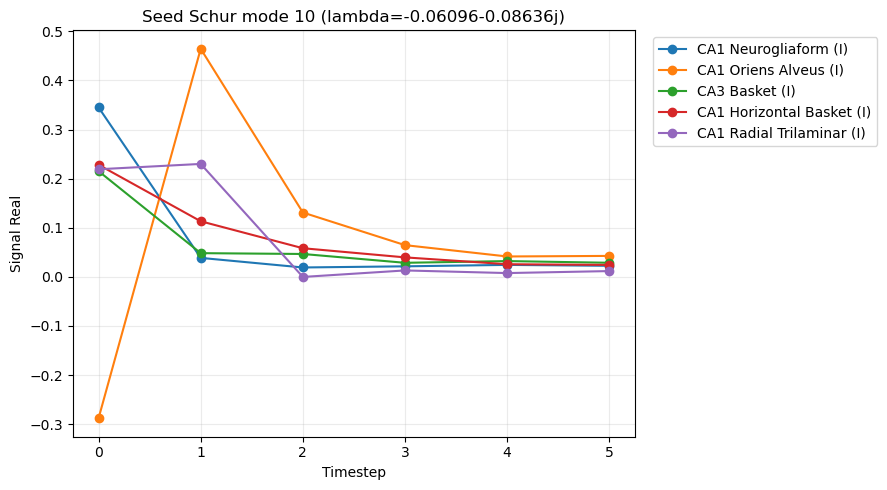

In [6]:
plot_seed_mode_cell_types(
    all_mode_signals, mode=mode_to_view, value='signal_real'
);

## Compare cascade propagation with the isolated mode

The isolated version excludes transfer to other Schur coordinates and therefore follows $q_k\lambda_k^t$ exactly.

In [7]:
isolated_mode = propagate_mode_cell_types(
    model, mode=mode_to_view, timesteps=10, top_n=5, coupled=False
)
isolated_mode.pivot(
    index='timestep', columns='cell_type', values='signal_real'
).round(6)

cell_type,CA1 Horizontal Basket (I),CA1 Neurogliaform (I),CA1 Oriens Alveus (I),CA1 Radial Trilaminar (I),CA3 Basket (I)
timestep,,,,,
0,0.228188,0.345072,-0.288080,0.219071,0.215235
1,-0.013746,-0.015108,0.013600,-0.012595,-0.029756
2,-0.000874,-0.002014,0.001561,-0.000912,0.001223
3,0.000260,0.000414,-0.000342,0.000252,0.000183
4,-0.000022,-0.000028,0.000024,-0.000021,-0.000036
5,-0.000000,-0.000001,0.000001,-0.000000,0.000002
6,0.000000,0.000000,-0.000000,0.000000,0.000000
7,-0.000000,-0.000000,0.000000,-0.000000,-0.000000
8,0.000000,0.000000,-0.000000,0.000000,0.000000


## Mode loadings and anatomical summaries

The following tables consolidate the former draft EDA. Mode indexes remain zero-based and preserve the original Schur ordering. A high-loading cell has `|Q[cell, mode]| > HIGH_LOADING_THRESHOLD`.

In [8]:
mij = load_mij_data(MATRIX_PATH, NETLIST_PATH)
assert list(model.labels) == mij.labels

loadings = schur_mode_loadings(model, mij.ei.to_dict())
display(loadings.head(15))

,mode,eigenvalue_real,eigenvalue_imag,eigenvalue_magnitude,cell_index,cell_type,region,ei,loading_rank,loading_real,loading_imag,loading_magnitude,energy_fraction
0,0,0.95,0.0,0.95,78,MEC LIII Superficial Multipolar Interneuron (I),MEC,i,1,0.670392,0.000046,0.670392,0.449426
1,0,0.95,0.0,0.95,27,CA1 Trilaminar (I),CA1,i,2,0.492789,0.000034,0.492789,0.242841
2,0,0.95,0.0,0.95,17,CA1 Perforant Path Associated QuadD (I),CA1,i,3,0.287424,0.000020,0.287424,0.082612
3,0,0.95,0.0,0.95,16,CA1 Perforant Path Associated (I),CA1,i,4,0.227403,0.000016,0.227403,0.051712
4,0,0.95,0.0,0.95,48,DG Axo Axonic (I),DG,i,5,0.194089,0.000013,0.194089,0.037671
5,0,0.95,0.0,0.95,47,DG AIPRIM (I),DG,i,6,0.137738,0.000010,0.137738,0.018972
6,0,0.95,0.0,0.95,20,CA1 R Receiving Apical Targeting (I),CA1,i,7,0.129840,0.000009,0.129840,0.016859
7,0,0.95,0.0,0.95,13,CA1 OR LM (I),CA1,i,8,0.089870,0.000006,0.089870,0.008077
8,0,0.95,0.0,0.95,8,CA1 LMR (I),CA1,i,9,0.087429,0.000006,0.087429,0.007644
9,0,0.95,0.0,0.95,3,CA1 Basket CCK+ (I),CA1,i,10,0.082854,0.000006,0.082854,0.006865


### Mode and region summaries

In [9]:
mode_summary = summarize_schur_modes(loadings, HIGH_LOADING_THRESHOLD)
region_summary = summarize_schur_regions(mode_summary)
display(mode_summary)
display(region_summary)

,mode,dominant_region,dominant_cell_type,dominant_loading,eigenvalue_real,eigenvalue_imag,eigenvalue_magnitude,n_high_loading_cells,n_high_loading_inhibitory,high_loading_inhibitory_cells
3,3,CA1,CA1 Trilaminar (I),0.584300,0.028286,3.099216e-01,0.311210,31,24,"CA1 Trilaminar (I), CA1 Perforant Path Associa..."
5,5,CA1,CA1 Perforant Path Associated (I),0.370415,-0.181766,2.043759e-16,0.181766,31,20,"CA1 Perforant Path Associated (I), CA1 Radial ..."
7,7,CA1,CA1 R Receiving Apical Targeting (I),0.443261,-0.042630,1.059215e-01,0.114178,34,26,"CA1 R Receiving Apical Targeting (I), CA1 Perf..."
10,10,CA1,CA1 Neurogliaform (I),0.351835,-0.060965,-8.636200e-02,0.105712,42,30,"CA1 Neurogliaform (I), CA1 Oriens Alveus (I), ..."
8,8,CA1,CA1 R Receiving Apical Targeting (I),0.428715,-0.060965,8.636200e-02,0.105712,38,30,"CA1 R Receiving Apical Targeting (I), DG Axo A..."
...,...,...,...,...,...,...,...,...,...,...
53,53,MEC,MEC LII III Pyramidal Multiform (E),0.298860,-0.000643,-3.894260e-04,0.000752,46,29,"CA1 Axo Axonic (I), MEC LIII Superficial Trila..."
59,59,MEC,MEC LII III Pyramidal Multiform (E),0.253411,0.000206,-1.548051e-04,0.000258,55,32,"CA3 Axo Axonic (I), CA3 Mossy Fiber Associated..."
83,83,MEC,MEC LV Pyramidal (E),0.449210,0.000008,-2.529439e-21,0.000008,24,5,"DG Neurogliaform (I), DG MOPP (I), DG HIPP (I)..."
80,80,MEC,MEC LII III Pyramidal Multiform (E),0.419283,0.000007,2.800452e-21,0.000007,34,12,"CA1 O LM (I), MEC LIII Superficial Trilayered ..."


,n_modes,mean_high_loading_inhibitory,max_high_loading_inhibitory,mean_dominant_loading
dominant_region,,,,
CA1,26,25.461538,33,0.428746
CA3,15,27.666667,32,0.402757
DG,15,26.200000,35,0.416675
MEC,12,22.166667,32,0.458094
CA2,8,26.875000,33,0.416097
EC,7,24.857143,35,0.439827
LEC,1,32.000000,32,0.384295
SUB,1,31.000000,31,0.430800


### Inspect or filter individual modes

In [10]:
MODE_TO_INSPECT = 0
MIN_LOADING_TO_SHOW = 0.05

columns = [
    'loading_rank', 'cell_type', 'region', 'ei',
    'loading_real', 'loading_imag', 'loading_magnitude', 'energy_fraction',
]
display(loadings.query(
    'mode == @MODE_TO_INSPECT and loading_magnitude > @MIN_LOADING_TO_SHOW'
)[columns])

,loading_rank,cell_type,region,ei,loading_real,loading_imag,loading_magnitude,energy_fraction
0,1,MEC LIII Superficial Multipolar Interneuron (I),MEC,i,0.670392,0.000046,0.670392,0.449426
1,2,CA1 Trilaminar (I),CA1,i,0.492789,0.000034,0.492789,0.242841
2,3,CA1 Perforant Path Associated QuadD (I),CA1,i,0.287424,0.000020,0.287424,0.082612
3,4,CA1 Perforant Path Associated (I),CA1,i,0.227403,0.000016,0.227403,0.051712
4,5,DG Axo Axonic (I),DG,i,0.194089,0.000013,0.194089,0.037671
5,6,DG AIPRIM (I),DG,i,0.137738,0.000010,0.137738,0.018972
6,7,CA1 R Receiving Apical Targeting (I),CA1,i,0.129840,0.000009,0.129840,0.016859
7,8,CA1 OR LM (I),CA1,i,0.089870,0.000006,0.089870,0.008077
8,9,CA1 LMR (I),CA1,i,0.087429,0.000006,0.087429,0.007644
9,10,CA1 Basket CCK+ (I),CA1,i,0.082854,0.000006,0.082854,0.006865


## Export propagation and reusable mode tables

This saves the propagation table, exact Schur arrays, tidy loading tables, regional summaries, and metadata under `outputs/schur_modes`.

In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
all_mode_signals.to_csv(OUTPUT_DIR / 'schur_mode_cell_type_propagation.csv', index=False)
saved_to = save_schur_mode_outputs(
    model, loadings, mode_summary, region_summary, OUTPUT_DIR,
    matrix_path=MATRIX_PATH,
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
    high_loading_threshold=HIGH_LOADING_THRESHOLD,
)
print(f'Exported {len(all_mode_signals):,} propagation rows to {saved_to}')

Exported 2,550 propagation rows to C:\Users\ranic\Documents\GitHub\schur_decomp\outputs\schur_modes
